In [9]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load California Housing dataset (built into scikit-learn)
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 1: Load Dataset
California Housing dataset load kiya seedha scikit-learn se (as_frame=True se pandas DataFrame mein). Ismein features hain jaise MedInc (income), HouseAge, AveRooms, Population, etc., aur target hai MedHouseVal (median house value).

In [10]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistics:")
print(df.describe())

Shape: (20640, 9)

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  206

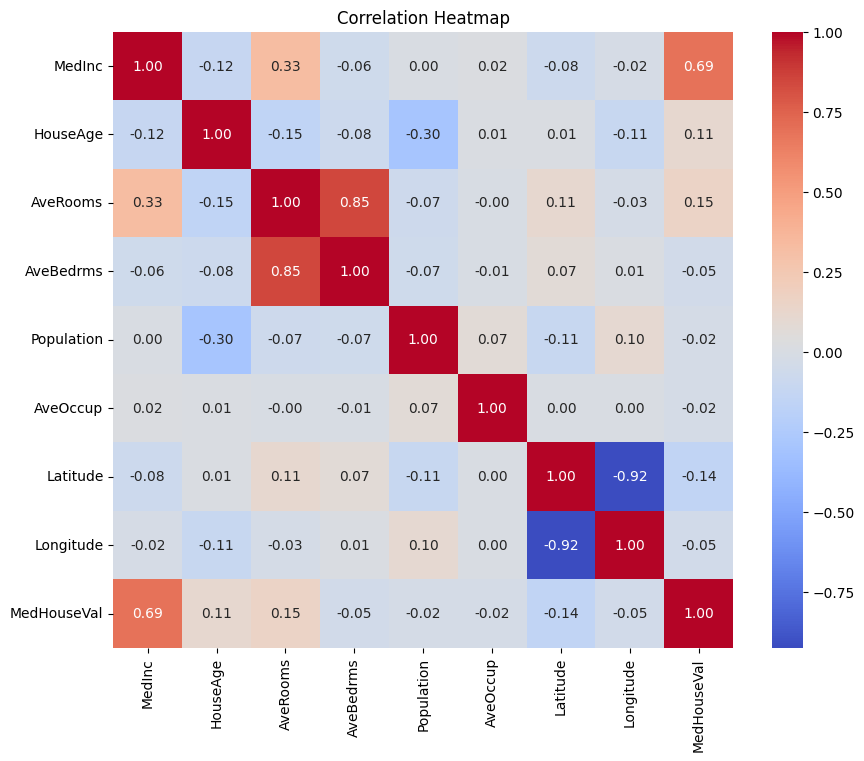

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

## Step 2: Exploratory Data Analysis
Dataset mein koi missing values nahi hain. Correlation heatmap se pata chala MedInc (income) ka MedHouseVal ke saath sabse strong positive correlation hai.

In [12]:
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (16512, 8)
Testing set size: (4128, 8)


## Step 3: Train/Test Split
Data ko 80% training aur 20% testing mein split kiya, taaki model ko unseen data pe evaluate kar sakein.

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model training complete!")

Model training complete!


In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE (Mean Absolute Error): {mae:.3f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

MAE (Mean Absolute Error): 0.533
RMSE (Root Mean Squared Error): 0.746
R² Score: 0.576


## Step 4: Model Training & Evaluation
Linear Regression model train kiya. Evaluation metrics: MAE, RMSE, aur R² Score calculate kiye jo model ki accuracy dikhate hain.

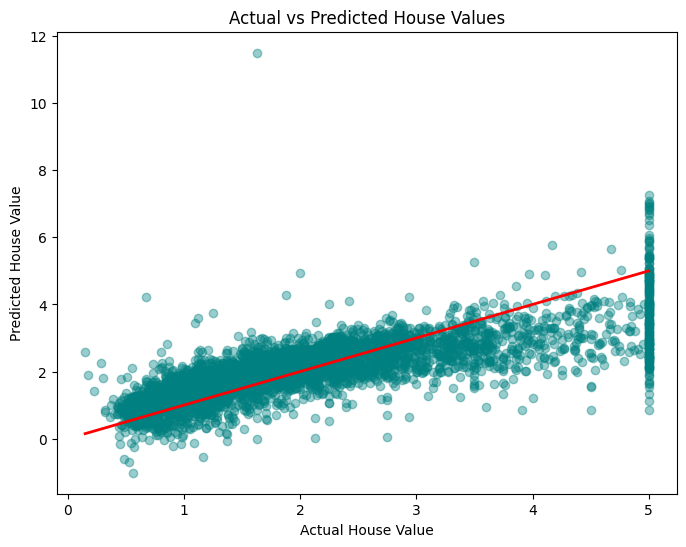

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.show()

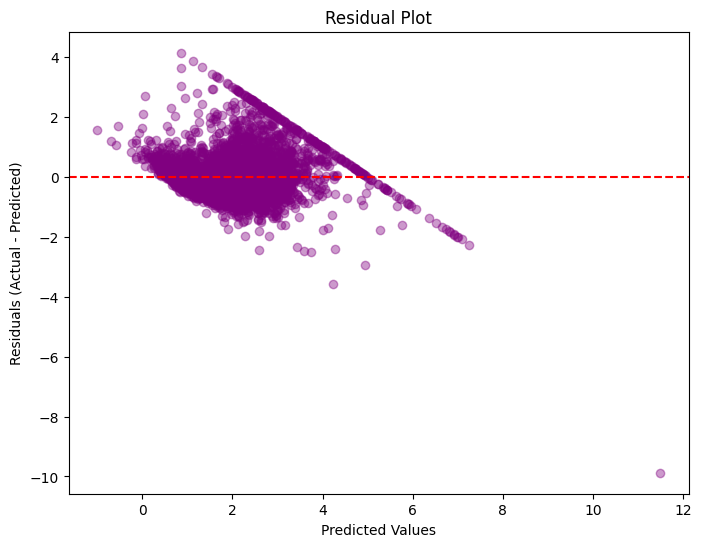

In [16]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.4, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

## Conclusion

- California Housing dataset pe Linear Regression model train kiya
- Model performance: MAE = 0.533, RMSE = 0.746, R² = 0.576
- R² Score 0.576 dikhata hai model house price ka 57.6% variation explain kar pa raha hai — simple Linear Regression ke liye decent result hai
- Income (MedInc) sabse strong predictor tha house price ka (correlation 0.69)
- Actual vs Predicted graph dikhata hai model reasonably achi tarah predict kar raha hai, halaanki kuch error hai jo real-world data mein normal hai
- Residual plot mein ek diagonal pattern dikha jo dataset ke capped values (houses jinki value $500,000 se upar hai unko capped kiya gaya hai) ki wajah se hai

### Skills Applied
✅ Data loading with scikit-learn
✅ Exploratory Data Analysis (correlation heatmap)
✅ Train/test split
✅ Linear Regression model training
✅ Model evaluation (MAE, RMSE, R²)
✅ Visualization (scatter plots, residuals)